Performs logistic regression on `mcts2.txt`, a CSV generated by `bin/mcts2.rs` with the following:

- `black_rollouts` number of MCTS rollouts performed by the black player (goes first)
- `white_rollouts` number of MCTS rollouts performed by the white player (goes second)
- `result` 1 or 0 depending on whether black won

1000 matchups were generated randomly with $121^X$ rollouts per player, where $X$ is selected uniformly from $2.0$ to $3.5$. $X$ is expected to be roughly proportional to the depth of the tree explored by that player.

In [1]:
import csv
import math
import numpy as np

xs = []
ys = []
with open('mcts2.txt') as f:
    reader = csv.DictReader(f)
    for row in reader:
        black_rollouts = float(row['black_rollouts'])
        white_rollouts = float(row['white_rollouts'])
        xs.append(math.log10(black_rollouts / white_rollouts))
        ys.append(float(row['result']))

xs = np.array(xs)
ys = np.array(ys)

np.stack([xs, ys]).shape

(2, 1000)

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(xs.reshape((-1, 1)), ys)
model.n_iter_

array([7], dtype=int32)

b0 = 0.29512299250673585
b1 = 1.7682802792137449


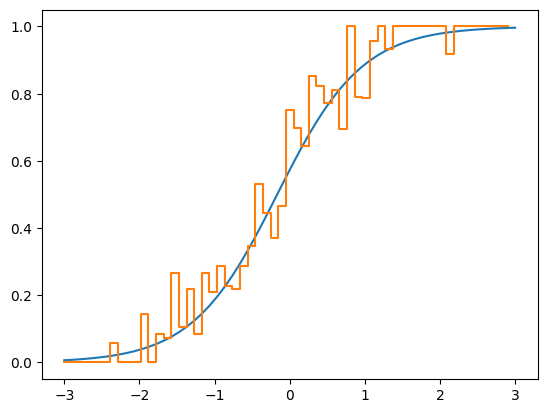

In [3]:
import matplotlib.pyplot as plt

b0 = model.intercept_[0]
b1 = model.coef_[0,0]
print('b0 =', b0)
print('b1 =', b1)

def predict(x):
    return 1. / (1. + np.exp(-(b0 + b1 * x)))

x = np.linspace(-3, 3, 60)
y = predict(x)

lose_hist, lose_edge = np.histogram(xs[ys < 0.5], bins=x)
wins_hist, wins_edge = np.histogram(xs[ys > 0.5], bins=x)

plt.plot(x, y)
#plt.scatter(xs, ys)
plt.step(lose_edge[:-1], wins_hist / (lose_hist + wins_hist))
plt.show()

In [4]:
x = np.arange(-2, 2, 0.5)
y = predict(x)
print(np.stack([x, y]).T)

[[-2.          0.03763579]
 [-1.5         0.08648748]
 [-1.          0.1864632 ]
 [-0.5         0.3568604 ]
 [ 0.          0.57324986]
 [ 0.5         0.76481529]
 [ 1.          0.88729495]
 [ 1.5         0.95014725]]


In [5]:
def to_mcts(x):
    return np.pow(10.0, x)
def to_elo(x):
    return 400.0 * (b0 + b1 * x)

x = np.arange(-1, 2.01, 0.25)
y = to_elo(x)+1500
x = to_mcts(x)*100000
print(f'{'ROLLOUTS':>10} {'ELO':>10}')
for x, y in zip(x, y):
    print(f'{x:10.0f} {y:10.0f}')

  ROLLOUTS        ELO
     10000        911
     17783       1088
     31623       1264
     56234       1441
    100000       1618
    177828       1795
    316228       1972
    562341       2149
   1000000       2325
   1778279       2502
   3162278       2679
   5623413       2856
  10000000       3033


The above table shows the effective Elo rating of the black player when using the given number of rollouts and playing against a white player with elo 1500 and using 100,000 rollouts.